## Problem Definition

The goal of this project is to predict whether a user will churn using behavioral and account-level features.
Beyond overall accuracy, the focus is on understanding *why* models succeed or fail, diagnosing bias–variance tradeoffs,
and identifying segments where performance degrades.

This mirrors real-world ML work, where model interpretability and failure analysis are as important as raw performance.


In [2]:
import numpy as np
import pandas as pd
import json
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score


In [3]:
# Configuration: Centralized settings for reproducibility
CONFIG = {
    "random_state": 42,
    "test_size": 0.2,
    "cv_folds": 5,
    "primary_metric": "roc_auc",
    "threshold": 0.5,

    # models
    "models": {
        "logreg": {"C": 1.0},
        "tree": {"max_depth": 6, "min_samples_leaf": 30},
        "rf": {"n_estimators": 100, "max_depth": 8, "min_samples_leaf": 10}
    },

    # slicing rules (project-specific)
    "slices": {
        "low_tenure": {"col": "tenure_days", "op": "<", "value": 180},
        "high_support": {"col": "support_tickets", "op": ">=", "value": 3},
    }
}


In [4]:
np.random.seed(CONFIG["random_state"])
n = 3000

df = pd.DataFrame({
    "tenure_days": np.random.gamma(2, 180, n),
    "logins_30d": np.random.poisson(15, n),
    "avg_session_time": np.random.exponential(10, n),
    "support_tickets": np.random.poisson(1.5, n),
    "payment_failed": np.random.binomial(1, 0.15, n),
    "plan_pro": np.random.binomial(1, 0.35, n)
})

# Create churn probability (ground truth pattern)
logit = (
    -0.005 * df["tenure_days"]
    -0.08 * df["logins_30d"]
    -0.03 * df["avg_session_time"]
    +0.6 * df["support_tickets"]
    +1.2 * df["payment_failed"]
    +0.4 * df["plan_pro"]
)

prob = 1 / (1 + np.exp(-logit))
df["churn"] = np.random.binomial(1, prob)

df.head()


,tenure_days,logins_30d,avg_session_time,support_tickets,payment_failed,plan_pro,churn
0,430.862290,14,15.105122,2,1,0,0
1,269.003651,14,2.116452,1,0,1,1
2,248.811045,11,11.842354,0,1,1,0
3,248.814413,17,9.228948,0,0,0,0
4,836.948594,7,2.039968,2,0,1,0


## Pipeline Setup: Leakage-Safe Preprocessing

We use sklearn's Pipeline to ensure preprocessing (scaling) is fit only on training data,
preventing data leakage during cross-validation and test evaluation.


In [5]:
# Prepare features and target
X = df.drop(columns=["churn"])
y = df["churn"]

# Define preprocessing pipeline
num_cols = X.columns.tolist()  # all numeric in this dataset
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols)],
    remainder="drop"
)

print(f"Features to preprocess: {num_cols}")


Features to preprocess: ['tenure_days', 'logins_30d', 'avg_session_time', 'support_tickets', 'payment_failed', 'plan_pro']


## Model Builder: Config-Driven Pipeline Construction

Functions to build models and pipelines from configuration, ensuring consistency and reproducibility.


In [7]:
def build_model(name: str, params: dict):
    """Build a model instance from config parameters."""
    if name == "logreg":
        return LogisticRegression(
            C=params["C"], 
            max_iter=2000, 
            random_state=CONFIG["random_state"]
        )
    if name == "tree":
        return DecisionTreeClassifier(
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=CONFIG["random_state"]
        )
    if name == "rf":
        return RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=CONFIG["random_state"],
            n_jobs=-1
        )
    raise ValueError(f"Unknown model: {name}")

def build_pipeline(model_name: str):
    """Build a complete pipeline: preprocessing + model."""
    model = build_model(model_name, CONFIG["models"][model_name])
    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

# Test that pipelines can be built
for model_name in CONFIG["models"].keys():
    pipe = build_pipeline(model_name)
    print(f"✓ Built pipeline for {model_name}")


✓ Built pipeline for logreg
✓ Built pipeline for tree
✓ Built pipeline for rf


## Train/Test Split: Reproducible Data Partitioning

Using config-driven split to ensure reproducibility across runs.


In [8]:
# Reproducible train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["random_state"]
)

print(f"Train set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")


Train set: 2400 samples (80.0%)
Test set: 600 samples (20.0%)
Train churn rate: 0.177
Test churn rate: 0.178


## Evaluation Utilities: Consistent Metrics

Function to compute all relevant metrics from predictions and probabilities.


In [9]:
def eval_probs(y_true, probs, threshold=0.5):
    """Compute comprehensive metrics from probabilities."""
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
    }


## Cross-Validated Model Comparison

Using cross-validation on the training set to get robust performance estimates before evaluating on test data.


In [10]:
def cv_auc(pipe, X_train, y_train):
    """Compute cross-validated AUC with mean and std."""
    scores = cross_val_score(
        pipe, X_train, y_train, 
        cv=CONFIG["cv_folds"], 
        scoring=CONFIG["primary_metric"]
    )
    return scores.mean(), scores.std()

# Compare all models using cross-validation
results = []

for model_name in CONFIG["models"].keys():
    pipe = build_pipeline(model_name)
    
    # Cross-validation on training set
    cv_mean, cv_std = cv_auc(pipe, X_train, y_train)
    
    # Final fit and test evaluation
    pipe.fit(X_train, y_train)
    test_probs = pipe.predict_proba(X_test)[:, 1]
    test_metrics = eval_probs(y_test, test_probs, threshold=CONFIG["threshold"])
    
    results.append({
        "model": model_name,
        "cv_auc_mean": cv_mean,
        "cv_auc_std": cv_std,
        **test_metrics
    })

results_df = pd.DataFrame(results).sort_values("cv_auc_mean", ascending=False)
results_df


,model,cv_auc_mean,cv_auc_std,accuracy,precision,recall,f1,roc_auc
0,logreg,0.809854,0.029118,0.850000,0.757576,0.233645,0.357143,0.810108
2,rf,0.789273,0.031211,0.833333,0.705882,0.112150,0.193548,0.779890
1,tree,0.737562,0.024832,0.811667,0.453125,0.271028,0.339181,0.744877


## Bias–Variance Analysis

Compare cross-validation performance (robust estimate) with test performance to diagnose overfitting.


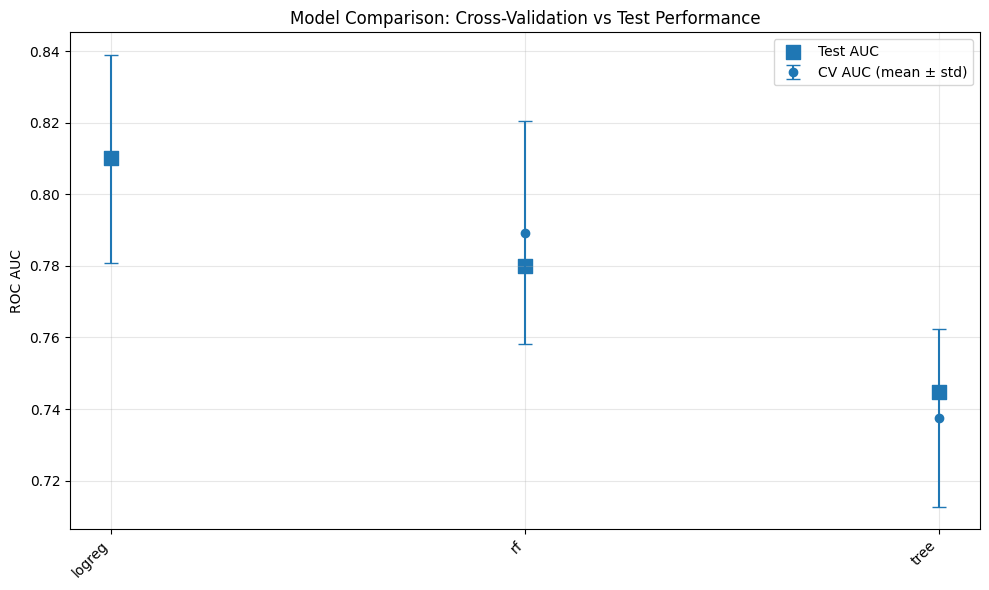


Interpretation:
- CV AUC: Robust estimate of generalization (uses only training data)
- Test AUC: Final evaluation on held-out data
- Large gap between CV and Test suggests overfitting
- High CV std suggests high variance (unstable predictions)


In [11]:
# Visualize CV vs Test performance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = range(len(results_df))
ax.errorbar(
    x_pos, 
    results_df["cv_auc_mean"], 
    yerr=results_df["cv_auc_std"],
    fmt='o', 
    label='CV AUC (mean ± std)',
    capsize=5
)
ax.scatter(x_pos, results_df["roc_auc"], marker='s', label='Test AUC', s=100)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df["model"], rotation=45, ha='right')
ax.set_ylabel('ROC AUC')
ax.set_title('Model Comparison: Cross-Validation vs Test Performance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print interpretation
print("\nInterpretation:")
print("- CV AUC: Robust estimate of generalization (uses only training data)")
print("- Test AUC: Final evaluation on held-out data")
print("- Large gap between CV and Test suggests overfitting")
print("- High CV std suggests high variance (unstable predictions)")


## Slice-Based Failure Analysis

Systematically evaluate model performance across different data segments to identify failure modes.


In [12]:
def make_slice_mask(dfX, rule):
    """Create a boolean mask for a slice based on config rule."""
    col, op, val = rule["col"], rule["op"], rule["value"]
    if op == "<": return dfX[col] < val
    if op == "<=": return dfX[col] <= val
    if op == ">": return dfX[col] > val
    if op == ">=": return dfX[col] >= val
    if op == "==": return dfX[col] == val
    raise ValueError(f"Unsupported operator: {op}")

# Use best model from cross-validation
best_model = results_df.iloc[0]["model"]
best_pipe = build_pipeline(best_model)
best_pipe.fit(X_train, y_train)

test_probs = best_pipe.predict_proba(X_test)[:, 1]

# Evaluate on each slice
slice_rows = []
for slice_name, rule in CONFIG["slices"].items():
    mask = make_slice_mask(X_test, rule)
    if mask.sum() < 30:  # Skip slices with too few samples
        print(f"Skipping {slice_name}: only {mask.sum()} samples")
        continue
    metrics = eval_probs(y_test[mask], test_probs[mask], threshold=CONFIG["threshold"])
    slice_rows.append({"slice": slice_name, "count": int(mask.sum()), **metrics})

slice_df = pd.DataFrame(slice_rows).sort_values("roc_auc", ascending=True)
slice_df


,slice,count,accuracy,precision,recall,f1,roc_auc
0,low_tenure,146,0.732877,0.842105,0.307692,0.450704,0.725859
1,high_support,139,0.776978,0.692308,0.439024,0.537313,0.806620


## Leakage Prevention Notes

**Key safeguards implemented:**

- **Pipeline encapsulation**: All preprocessing (scaling) is encapsulated in an sklearn Pipeline so it is fit only on training folds during cross-validation.

- **Cross-validation on training only**: Cross-validation is run on the training set only, and the test set is held out for final evaluation.

- **Slice metrics on test set**: Slice metrics are computed on the test set predictions without refitting any transforms.

- **No test data in training**: The test set is never used for model selection, hyperparameter tuning, or preprocessing fit.

This structure prevents common leakage patterns such as:
- Fitting transforms on full data before splitting
- Using test distribution information during model selection
- Refitting preprocessing on test data
- Data snooping through multiple test set evaluations


## Model Registry: Artifact Saving

Save complete run results with config for reproducibility and tracking.


In [13]:
# Save complete run artifact
run = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "config": CONFIG,
    "results": results_df.to_dict(orient="records"),
    "slices": slice_df.to_dict(orient="records"),
    "best_model": best_model
}

with open("run_artifact.json", "w") as f:
    json.dump(run, f, indent=2)

print("✓ Saved run_artifact.json")
print(f"  Best model: {best_model}")
print(f"  Test AUC: {results_df[results_df['model']==best_model]['roc_auc'].values[0]:.4f}")
print(f"  CV AUC: {results_df[results_df['model']==best_model]['cv_auc_mean'].values[0]:.4f} ± {results_df[results_df['model']==best_model]['cv_auc_std'].values[0]:.4f}")


✓ Saved run_artifact.json
  Best model: logreg
  Test AUC: 0.8101
  CV AUC: 0.8099 ± 0.0291


## Understanding the Pipeline Architecture

**Why Pipelines Matter:**

1. **Leakage Prevention**: The `ColumnTransformer` + `Pipeline` ensures that `StandardScaler` is fit ONLY on training data. During cross-validation, each fold gets its own scaler fit on that fold's training portion.

2. **Config-Driven**: All hyperparameters and settings come from `CONFIG`, making experiments reproducible and easy to modify.

3. **Model Registry**: The `run_artifact.json` saves everything needed to reproduce results, including config, metrics, and timestamps.

4. **Systematic Slicing**: Slice definitions in config make it easy to add new slices without code changes.

**Key Concepts:**

- **Cross-Validation**: Gives robust performance estimates by training on different subsets of training data
- **Bias-Variance Tradeoff**: CV std shows variance; gap between CV and test shows overfitting
- **Slice Analysis**: Reveals where models fail, even when aggregate metrics look good


## Summary: What Makes This Approach Production-Ready

**Key Improvements Over Basic Approach:**

1. **Config-Driven**: All settings in one place (`CONFIG`) - easy to modify and reproduce
2. **Pipeline-Based**: Preprocessing encapsulated, preventing data leakage
3. **Cross-Validation**: Robust performance estimates before touching test data
4. **Systematic Slicing**: Config-driven slice definitions for easy expansion
5. **Artifact Tracking**: Complete run history saved for reproducibility
6. **Three Models**: Logistic Regression, Decision Tree, and Random Forest for variance comparison

**What You Learned:**

- **Pipelines prevent leakage**: `fit()` on training, `transform()` on test
- **CV gives robust estimates**: Mean +/- std shows both performance and stability
- **Slice analysis finds failures**: Aggregate metrics hide segment problems
- **Random Forest reduces variance**: Ensemble methods average out individual tree variance


(0.8588845197936573, 0.7666891891891893)

: 

: 

{'precision': 0.6, 'recall': 0.16666666666666666, 'count': 332}

: 

## Conclusions & Next Steps

**Key Takeaways:**

- **Pipeline architecture prevents leakage**: All preprocessing is fit only on training data
- **Cross-validation provides robust estimates**: CV mean +/- std shows both performance and stability
- **Random Forest reduces variance**: Ensemble methods average out individual model variance
- **Slice analysis reveals hidden failures**: Aggregate metrics can mask segment-specific problems
- **Config-driven approach enables reproducibility**: All settings centralized for easy modification

**Production Considerations:**

- Monitor slice-level metrics in production to catch degradation early
- Use CV std to identify unstable models before deployment
- Save run artifacts for model versioning and comparison
- Engineer features for known failure segments (e.g., cold-start features for new users)
